In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.rcParams['font.family'] = 'Malgun Gothic'  # 한글 폰트
plt.rcParams['axes.unicode_minus'] = False
np.random.seed(42)

# ✅ 샘플 데이터 생성 (직원 100명)
n = 100
df = pd.DataFrame({
    '이름': [f'직원{i:03d}' for i in range(1, n+1)],
    '부서': np.random.choice(['개발', '기획', '디자인'], n, p=[0.5, 0.3, 0.2]),
    '나이': np.random.randint(25, 55, n),
    '경력': np.random.randint(1, 20, n),
    '급여': np.random.normal(4500, 800, n).astype(int)
})

# 이상치 인위적으로 삽입
df.loc[0, '급여'] = 15000   # 극단적 고급여
df.loc[1, '급여'] = 500     # 극단적 저급여
df.loc[2, '급여'] = -100    # 음수 오류값

# 결측치 인위적으로 삽입
df.loc[5:8, '급여'] = np.nan
df.loc[10:12, '나이'] = np.nan

print("✅ 샘플 데이터 생성 완료")
print(df.head(20))
print(f"\n데이터 크기: {df.shape}")

✅ 샘플 데이터 생성 완료
       이름   부서    나이  경력       급여
0   직원001   개발  31.0   6  15000.0
1   직원002  디자인  41.0   4    500.0
2   직원003   기획  44.0  11   -100.0
3   직원004   기획  53.0  17   5121.0
4   직원005   개발  28.0   6   5336.0
5   직원006   개발  54.0   5      NaN
6   직원007   개발  29.0   2      NaN
7   직원008  디자인  47.0   6      NaN
8   직원009   기획  31.0  11      NaN
9   직원010   기획  37.0  16   4573.0
10  직원011   개발   NaN  16   5004.0
11  직원012  디자인   NaN   1   5910.0
12  직원013  디자인   NaN   9   4684.0
13  직원014   개발  28.0   6   3852.0
14  직원015   개발  37.0  16   5345.0
15  직원016   개발  31.0   3   4541.0
16  직원017   개발  51.0   4   5197.0
17  직원018   기획  43.0  19   5352.0
18  직원019   개발  46.0   3   3732.0
19  직원020   개발  52.0  19   5605.0

데이터 크기: (100, 5)


### 1️⃣ 이상치 탐지 및 처리

1️⃣ 이상치 탐지 및 처리

[IQR] 하한: 2248, 상한: 7074
[IQR] 이상치 개수: 3개
      이름   부서       급여
0  직원001   개발  15000.0
1  직원002  디자인    500.0
2  직원003   기획   -100.0

[Z-Score] 이상치 개수: 2개
이상치 값: [15000.  -100.]

[처리 후] 급여 범위: 2248 ~ 7074


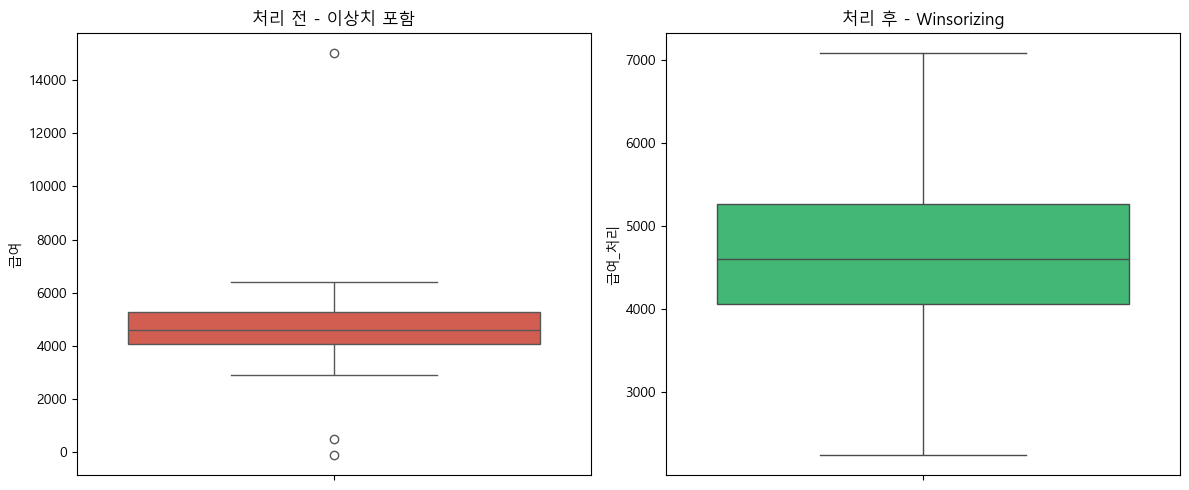

✅ 이상치 시각화 저장 완료


In [6]:
print("=" * 50)
print("1️⃣ 이상치 탐지 및 처리")
print("=" * 50)

# 결측치 제거 후 분석
급여 = df['급여'].dropna()

# ─── IQR 방법 ───────────────────────────────────
Q1 = 급여.quantile(0.25)
Q3 = 급여.quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_iqr = df[(df['급여'] < lower) | (df['급여'] > upper)]
print(f"\n[IQR] 하한: {lower:.0f}, 상한: {upper:.0f}")
print(f"[IQR] 이상치 개수: {len(outliers_iqr)}개")
print(outliers_iqr[['이름', '부서', '급여']])

# ─── Z-Score 방법 ───────────────────────────────
급여_clean = df['급여'].dropna()
z_scores = np.abs(stats.zscore(급여_clean))
outliers_z = 급여_clean[z_scores > 3]
print(f"\n[Z-Score] 이상치 개수: {len(outliers_z)}개")
print(f"이상치 값: {outliers_z.values}")

# ─── 이상치 처리: Winsorizing (경계값으로 대체) ──
df['급여_처리'] = df['급여'].clip(lower=lower, upper=upper)
print(f"\n[처리 후] 급여 범위: {df['급여_처리'].min():.0f} ~ {df['급여_처리'].max():.0f}")

# ─── 시각화 ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].set_title('처리 전 - 이상치 포함')
sns.boxplot(y=df['급여'], ax=axes[0], color='#e74c3c')

axes[1].set_title('처리 후 - Winsorizing')
sns.boxplot(y=df['급여_처리'], ax=axes[1], color='#2ecc71')

plt.tight_layout()
plt.savefig('outlier_boxplot.png', dpi=150)
plt.show()
print("✅ 이상치 시각화 저장 완료")

### 2️⃣ 기술통계

2️⃣ 기술통계 분석

[수치형 기술통계]
          나이     경력       급여
count  90.00  93.00    93.00
mean   40.60   9.53  4659.88
std     9.74   6.17   824.10
min    25.00   1.00  2904.00
25%    31.25   4.00  4127.00
50%    41.00   8.00  4602.00
75%    49.75  16.00  5256.00
max    54.00  19.00  6411.00

[범주형 포함 기술통계]
         부서           급여
count    93    93.000000
unique    3          NaN
top      개발          NaN
freq     50          NaN
mean    NaN  4659.881720
std     NaN   824.104492
min     NaN  2904.000000
25%     NaN  4127.000000
50%     NaN  4602.000000
75%     NaN  5256.000000
max     NaN  6411.000000

[급여 개별 통계]
  평균(mean):    4660 만원
  중앙값(median):4602 만원
  표준편차(std): 824 만원
  왜도(skew):    -0.044
  첨도(kurtosis):-0.556

[부서별 급여 통계]
         평균     중앙값   표준편차  인원수
부서                             
개발   4561.0  4544.0  801.0   50
기획   4711.0  4823.0  847.0   27
디자인  4884.0  4719.0  856.0   16

[부서별 다중 컬럼 통계]
         급여                    나이    경력
       mean     max     min  mean  mean
부서        

C:\Users\samsung\AppData\Local\Temp\ipykernel_11908\2790128956.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='부서', y='급여', ax=axes[0,1],


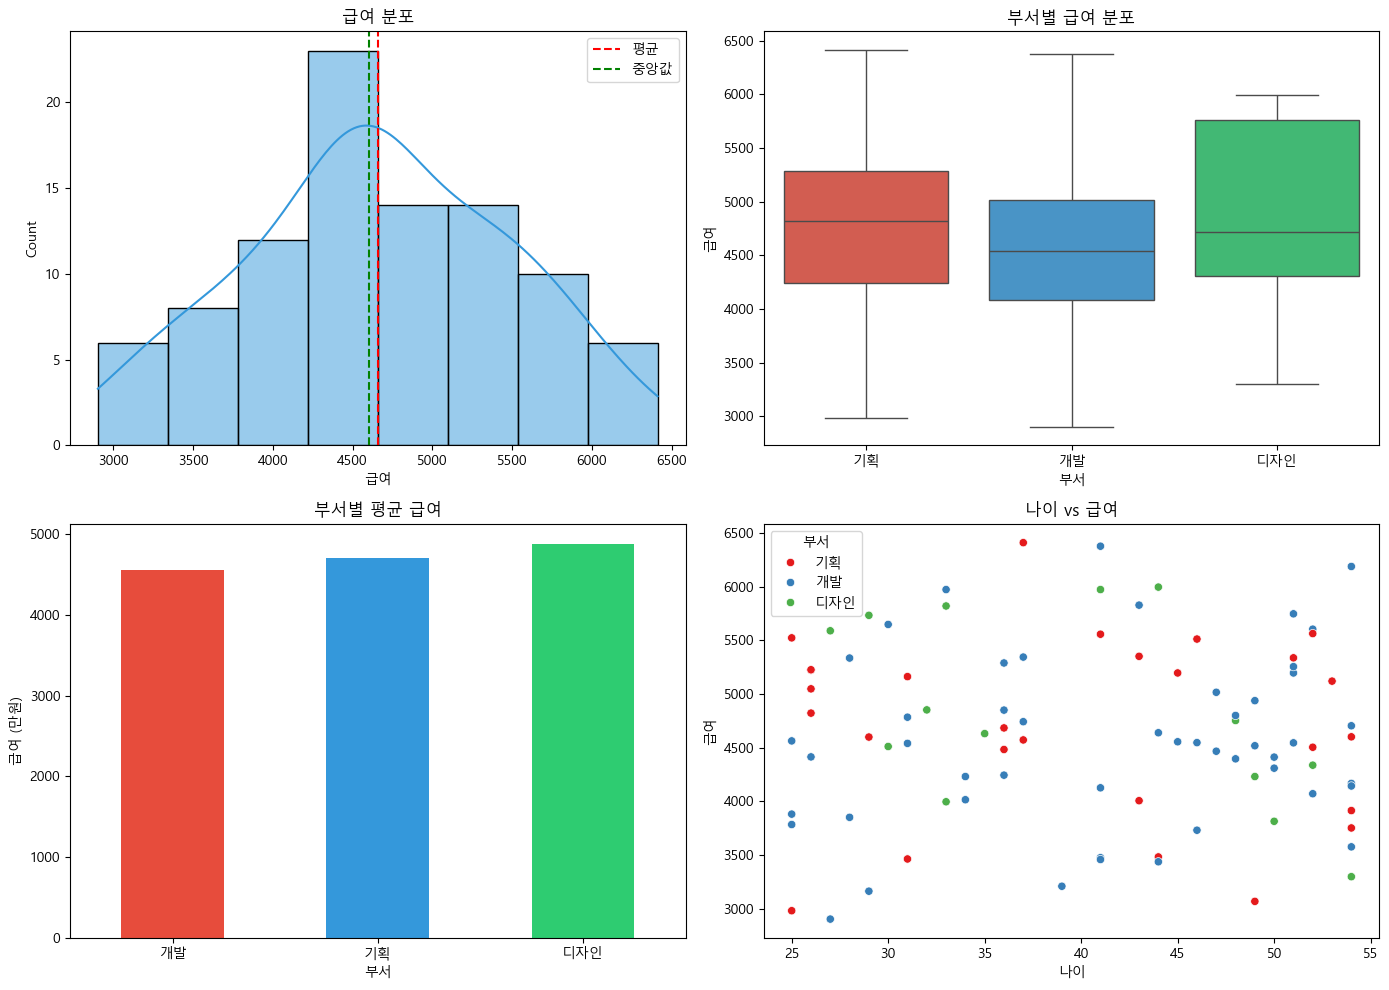

✅ 기술통계 시각화 저장 완료


In [7]:
print("=" * 50)
print("2️⃣ 기술통계 분석")
print("=" * 50)

# 이상치 제거된 데이터로 분석
df_clean = df[
    (df['급여'] >= lower) & (df['급여'] <= upper)
].copy()

# ─── describe() 전체 요약 ───────────────────────
print("\n[수치형 기술통계]")
print(df_clean[['나이', '경력', '급여']].describe().round(2))

print("\n[범주형 포함 기술통계]")
print(df_clean[['부서', '급여']].describe(include='all'))

# ─── 개별 통계 ──────────────────────────────────
print("\n[급여 개별 통계]")
print(f"  평균(mean):    {df_clean['급여'].mean():.0f} 만원")
print(f"  중앙값(median):{df_clean['급여'].median():.0f} 만원")
print(f"  표준편차(std): {df_clean['급여'].std():.0f} 만원")
print(f"  왜도(skew):    {df_clean['급여'].skew():.3f}")
print(f"  첨도(kurtosis):{df_clean['급여'].kurtosis():.3f}")

# ─── groupby 그룹별 통계 ────────────────────────
print("\n[부서별 급여 통계]")
group_stats = df_clean.groupby('부서')['급여'].agg(
    평균='mean', 중앙값='median', 표준편차='std', 인원수='count'
).round(0)
print(group_stats)

print("\n[부서별 다중 컬럼 통계]")
multi_stats = df_clean.groupby('부서').agg({
    '급여': ['mean', 'max', 'min'],
    '나이': 'mean',
    '경력': 'mean'
}).round(1)
print(multi_stats)

# ─── 시각화 ─────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 급여 분포 히스토그램
sns.histplot(df_clean['급여'], kde=True, ax=axes[0,0], color='#3498db')
axes[0,0].axvline(df_clean['급여'].mean(), color='red', linestyle='--', label='평균')
axes[0,0].axvline(df_clean['급여'].median(), color='green', linestyle='--', label='중앙값')
axes[0,0].set_title('급여 분포')
axes[0,0].legend()

# 부서별 급여 박스플롯
sns.boxplot(data=df_clean, x='부서', y='급여', ax=axes[0,1],
            palette=['#e74c3c','#3498db','#2ecc71'])
axes[0,1].set_title('부서별 급여 분포')

# 부서별 평균 급여 막대그래프
group_stats['평균'].plot(kind='bar', ax=axes[1,0],
    color=['#e74c3c','#3498db','#2ecc71'], rot=0)
axes[1,0].set_title('부서별 평균 급여')
axes[1,0].set_ylabel('급여 (만원)')

# 나이 vs 급여 산점도
sns.scatterplot(data=df_clean, x='나이', y='급여',
    hue='부서', ax=axes[1,1], palette='Set1')
axes[1,1].set_title('나이 vs 급여')

plt.tight_layout()
plt.savefig('descriptive_stats.png', dpi=150)
plt.show()
print("✅ 기술통계 시각화 저장 완료")

### 3️⃣ 상관분석

3️⃣ 상관분석

[Pearson 상관계수]
       나이     경력     급여
나이  1.000  0.076 -0.018
경력  0.076  1.000 -0.105
급여 -0.018 -0.105  1.000

[Spearman 상관계수]
       나이     경력     급여
나이  1.000  0.089 -0.052
경력  0.089  1.000 -0.058
급여 -0.052 -0.058  1.000

[상관계수 해석]
  나이 vs 급여: r=-0.018 → 약한 음의 상관관계
  경력 vs 급여: r=-0.105 → 약한 음의 상관관계


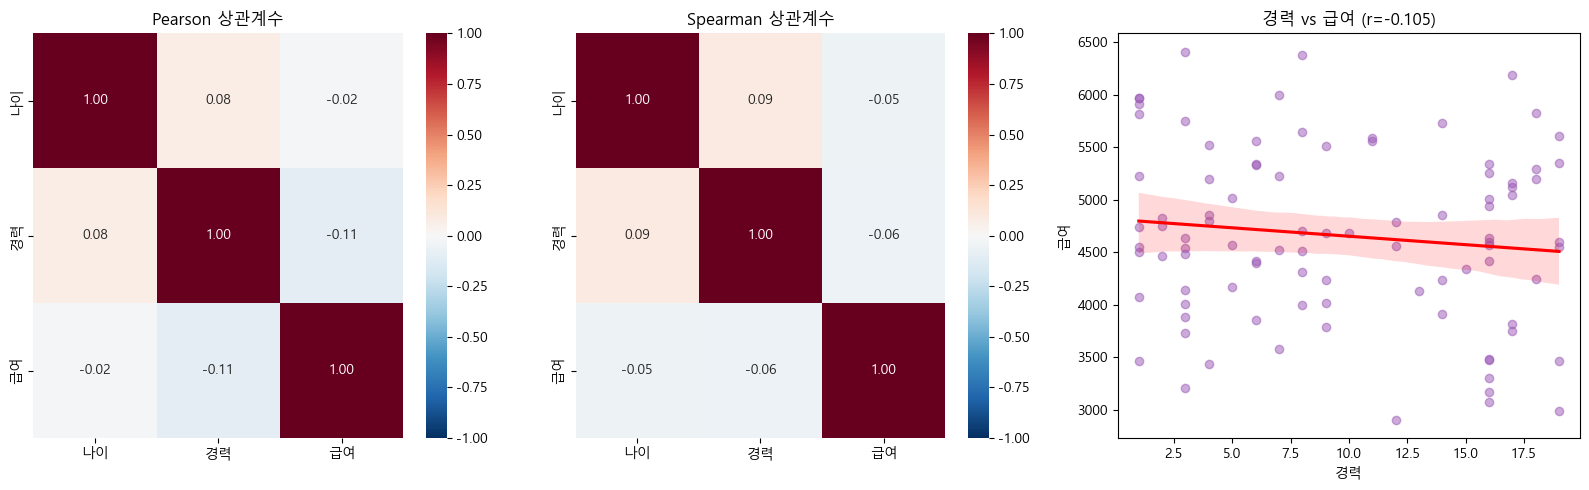

✅ 상관분석 시각화 저장 완료


In [8]:
print("=" * 50)
print("3️⃣ 상관분석")
print("=" * 50)

numeric_df = df_clean[['나이', '경력', '급여']].dropna()

# ─── Pearson 상관계수 ────────────────────────────
corr_pearson = numeric_df.corr(method='pearson')
print("\n[Pearson 상관계수]")
print(corr_pearson.round(3))

# ─── Spearman 상관계수 ───────────────────────────
corr_spearman = numeric_df.corr(method='spearman')
print("\n[Spearman 상관계수]")
print(corr_spearman.round(3))

# ─── 상관계수 해석 ──────────────────────────────
print("\n[상관계수 해석]")
for col1 in ['나이', '경력']:
    r = corr_pearson.loc[col1, '급여']
    strength = '약한' if abs(r) < 0.3 else ('중간' if abs(r) < 0.7 else '강한')
    direction = '양의' if r > 0 else '음의'
    print(f"  {col1} vs 급여: r={r:.3f} → {strength} {direction} 상관관계")

# ─── 시각화 ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Pearson 히트맵
sns.heatmap(corr_pearson, annot=True, cmap='RdBu_r',
    vmin=-1, vmax=1, center=0, fmt='.2f', ax=axes[0])
axes[0].set_title('Pearson 상관계수')

# Spearman 히트맵
sns.heatmap(corr_spearman, annot=True, cmap='RdBu_r',
    vmin=-1, vmax=1, center=0, fmt='.2f', ax=axes[1])
axes[1].set_title('Spearman 상관계수')

# 경력 vs 급여 산점도 + 회귀선
sns.regplot(data=df_clean, x='경력', y='급여',
    ax=axes[2], color='#9b59b6',
    scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
r_val = corr_pearson.loc['경력', '급여']
axes[2].set_title(f'경력 vs 급여 (r={r_val:.3f})')

plt.tight_layout()
plt.savefig('correlation_analysis.png', dpi=150)
plt.show()
print("✅ 상관분석 시각화 저장 완료")

### 4️⃣ 분산분석 (ANOVA)

In [ ]:
print("=" * 50)
print("4️⃣ 분산분석 (ANOVA)")
print("=" * 50)

# ─── 그룹별 데이터 분리 ──────────────────────────
dev    = df_clean[df_clean['부서'] == '개발']['급여'].dropna()
plan   = df_clean[df_clean['부서'] == '기획']['급여'].dropna()
design = df_clean[df_clean['부서'] == '디자인']['급여'].dropna()

print(f"\n부서별 인원 및 평균 급여:")
print(f"  개발팀:   {len(dev)}명, 평균 {dev.mean():.0f}만원")
print(f"  기획팀:   {len(plan)}명, 평균 {plan.mean():.0f}만원")
print(f"  디자인팀: {len(design)}명, 평균 {design.mean():.0f}만원")

# ─── 정규성 검정 (Shapiro-Wilk) ─────────────────
print("\n[정규성 검정 - Shapiro-Wilk]")
for name, data in [('개발', dev), ('기획', plan), ('디자인', design)]:
    stat, p = stats.shapiro(data)
    result = "정규분포 ✅" if p > 0.05 else "비정규분포 ❌"
    print(f"  {name}: W={stat:.4f}, p={p:.4f} → {result}")

# ─── 등분산 검정 (Levene) ───────────────────────
lev_stat, lev_p = stats.levene(dev, plan, design)
print(f"\n[등분산 검정 - Levene]")
print(f"  통계량={lev_stat:.4f}, p={lev_p:.4f}")
print(f"  → {'등분산 ✅' if lev_p > 0.05 else '이분산 ❌'}")

# ─── One-way ANOVA ──────────────────────────────
f_stat, p_value = stats.f_oneway(dev, plan, design)
print(f"\n[One-way ANOVA 결과]")
print(f"  F-통계량: {f_stat:.4f}")
print(f"  p-value:  {p_value:.4f}")
if p_value < 0.05:
    print("  → 부서별 급여 차이가 통계적으로 유의미합니다. ✅ (p < 0.05)")
else:
    print("  → 부서별 급여 차이가 통계적으로 유의미하지 않습니다. ❌")

# ─── 사후검정 (Tukey HSD) ───────────────────────
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(
    endog=df_clean['급여'].dropna(),
    groups=df_clean.loc[df_clean['급여'].notna(), '부서'],
    alpha=0.05
)
print(f"\n[Tukey HSD 사후검정]")
print(tukey)

# ─── 시각화 ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 부서별 분포 바이올린 플롯
sns.violinplot(data=df_clean, x='부서', y='급여',
    ax=axes[0], palette=['#e74c3c','#3498db','#2ecc71'], inner='box')
axes[0].set_title(f'부서별 급여 분포\n(ANOVA: F={f_stat:.2f}, p={p_value:.4f})')

# 평균 ± 95% 신뢰구간
means = [dev.mean(), plan.mean(), design.mean()]
sems  = [stats.sem(dev), stats.sem(plan), stats.sem(design)]
axes[1].bar(['개발', '기획', '디자인'], means,
    yerr=[1.96*s for s in sems],
    color=['#e74c3c','#3498db','#2ecc71'],
    capsize=8, error_kw={'elinewidth':2})
axes[1].set_title('부서별 평균 급여 (95% 신뢰구간)')
axes[1].set_ylabel('급여 (만원)')

plt.tight_layout()
plt.savefig('anova_result.png', dpi=150)
plt.show()
print("✅ ANOVA 시각화 저장 완료")

4️⃣ 분산분석 (ANOVA)

부서별 인원 및 평균 급여:
  개발팀:   50명, 평균 4561만원
  기획팀:   27명, 평균 4711만원
  디자인팀: 16명, 평균 4884만원

[정규성 검정 - Shapiro-Wilk]
  개발: W=0.9881, p=0.8918 → 정규분포 ✅
  기획: W=0.9471, p=0.1818 → 정규분포 ✅
  디자인: W=0.9246, p=0.2003 → 정규분포 ✅

[등분산 검정 - Levene]
  통계량=0.1814, p=0.8344
  → 등분산 ✅

[One-way ANOVA 결과]
  F-통계량: 1.0034
  p-value:  0.3707
  → 부서별 급여 차이가 통계적으로 유의미하지 않습니다. ❌


ModuleNotFoundError: No module named 'statsmodels'

: 

: 

: 

### 5️⃣ EDA 종합 프로세스 (한 번에 실행)

5️⃣ EDA 종합 실습 - Titanic 데이터셋

[STEP 1] 데이터 기본 정보
  크기: (891, 15)
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB
None

[STEP 2] 결측치 현황
       

C:\Users\samsung\AppData\Local\Temp\ipykernel_11908\1413967436.py:18: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  titanic['age'].fillna(titanic['age'].median(), inplace=True)
C:\Users\samsung\AppData\Local\Temp\ipykernel_11908\1413967436.py:19: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through 

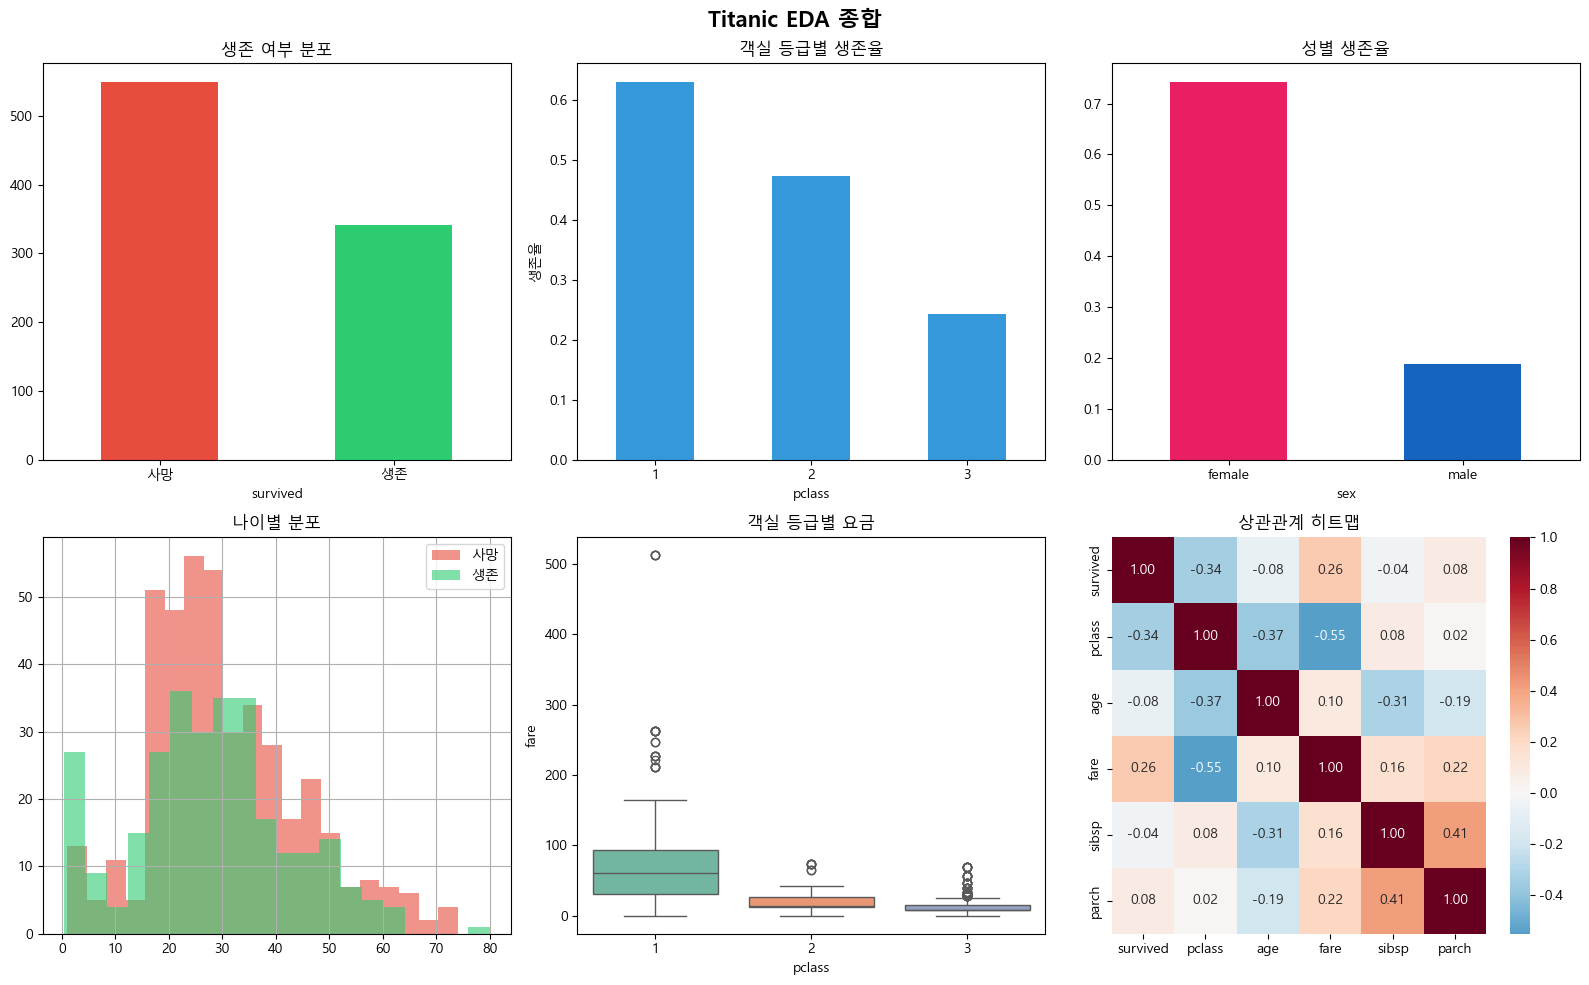


[STEP 6] EDA 인사이트 요약
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
전체 생존율  : 38.4%
여성 생존율  : 74.2%
남성 생존율  : 18.9%
1등석 생존율 : 63.0%
3등석 생존율 : 24.2%
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
주요 발견:
  ✅ 성별이 생존에 가장 큰 영향 (여성 생존율 압도적)
  ✅ 객실 등급이 높을수록 생존율 높음
  ✅ 나이가 어릴수록 생존율 상대적 높음

🎉 EDA 종합 분석 완료!


In [9]:
print("=" * 60)
print("5️⃣ EDA 종합 실습 - Titanic 데이터셋")
print("=" * 60)

# ─── STEP 1: 데이터 탐색 ────────────────────────
titanic = sns.load_dataset('titanic')
print(f"\n[STEP 1] 데이터 기본 정보")
print(f"  크기: {titanic.shape}")
print(titanic.info())

# ─── STEP 2: 결측치 처리 ────────────────────────
print(f"\n[STEP 2] 결측치 현황")
missing = titanic.isnull().sum()
missing_pct = (missing / len(titanic) * 100).round(1)
print(pd.DataFrame({'결측수': missing, '결측률(%)': missing_pct})
      [missing > 0])

titanic['age'].fillna(titanic['age'].median(), inplace=True)
titanic['embarked'].fillna(titanic['embarked'].mode()[0], inplace=True)
titanic.drop(columns=['deck'], inplace=True)  # 결측률 77% 제거
print("  → 처리 완료")

# ─── STEP 3: 기술통계 ───────────────────────────
print(f"\n[STEP 3] 기술통계")
print(titanic[['age','fare','survived']].describe().round(2))

# ─── STEP 4: 상관분석 ───────────────────────────
print(f"\n[STEP 4] 상관분석")
corr = titanic[['survived','pclass','age','fare','sibsp','parch']].corr()
print(corr['survived'].sort_values(ascending=False).round(3))

# ─── STEP 5: 시각화 ─────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Titanic EDA 종합', fontsize=16, fontweight='bold')

# 생존 여부 분포
titanic['survived'].value_counts().rename({0:'사망',1:'생존'}).plot(
    kind='bar', ax=axes[0,0], color=['#e74c3c','#2ecc71'], rot=0)
axes[0,0].set_title('생존 여부 분포')

# 객실 등급별 생존율
titanic.groupby('pclass')['survived'].mean().plot(
    kind='bar', ax=axes[0,1], color='#3498db', rot=0)
axes[0,1].set_title('객실 등급별 생존율')
axes[0,1].set_ylabel('생존율')

# 성별 생존율
titanic.groupby('sex')['survived'].mean().plot(
    kind='bar', ax=axes[0,2], color=['#e91e63','#1565c0'], rot=0)
axes[0,2].set_title('성별 생존율')

# 나이 분포 (생존/사망)
for s, color, label in [(0,'#e74c3c','사망'), (1,'#2ecc71','생존')]:
    titanic[titanic['survived']==s]['age'].hist(
        ax=axes[1,0], alpha=0.6, color=color, label=label, bins=20)
axes[1,0].set_title('나이별 분포')
axes[1,0].legend()

# 요금 분포
sns.boxplot(data=titanic, x='pclass', y='fare', ax=axes[1,1],
    palette='Set2')
axes[1,1].set_title('객실 등급별 요금')

# 상관관계 히트맵
sns.heatmap(corr, annot=True, cmap='RdBu_r',
    center=0, fmt='.2f', ax=axes[1,2])
axes[1,2].set_title('상관관계 히트맵')

plt.tight_layout()
plt.savefig('titanic_eda_final.png', dpi=150)
plt.show()

# ─── STEP 6: 인사이트 정리 ──────────────────────
print(f"""
[STEP 6] EDA 인사이트 요약
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
전체 생존율  : {titanic['survived'].mean():.1%}
여성 생존율  : {titanic[titanic['sex']=='female']['survived'].mean():.1%}
남성 생존율  : {titanic[titanic['sex']=='male']['survived'].mean():.1%}
1등석 생존율 : {titanic[titanic['pclass']==1]['survived'].mean():.1%}
3등석 생존율 : {titanic[titanic['pclass']==3]['survived'].mean():.1%}
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
주요 발견:
  ✅ 성별이 생존에 가장 큰 영향 (여성 생존율 압도적)
  ✅ 객실 등급이 높을수록 생존율 높음
  ✅ 나이가 어릴수록 생존율 상대적 높음
""")
print("🎉 EDA 종합 분석 완료!")

: 

: 

: 

: 

: 

: 

: 

: 

: 